In [1]:
# Part 3: Discussion & Analysis - Code part
import torch
import os
import platform
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Device:", torch.cuda.get_device_name(0))
    print("Python version:", platform.python_version())        
    print("Machine name:", platform.node()) # This is unique to the machine
    print("Working directory:", os.getcwd())
if torch.cuda.is_available():
    print("Initial GPU memory usage:")
    print(torch.cuda.memory_allocated() / 1024**2, "MB allocated")
    print(torch.cuda.memory_reserved() / 1024**2, "MB reserved")


cuda available: True
GPU Device: NVIDIA GeForce RTX 4090
Python version: 3.12.10
Machine name: wol06-424-pc
Working directory: w:\YaY\Project
Initial GPU memory usage:
0.0 MB allocated
0.0 MB reserved


In [2]:
import pandas as pd
from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from torchvision import transforms, models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import optuna
import wandb
import copy
import numpy as np
import time
from functools import partial
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
print(f"Cuda available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"Machine name: {platform.node()}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MB")

Cuda available: True
GPU Device: NVIDIA GeForce RTX 4090
Machine name: wol06-424-pc
Memory Allocated: 0.00 MB


In [3]:
classes_path = r"D:\COURSE_DATA\Intro_Deep_Learning\project\classes.csv"
image_dir = r"D:\COURSE_DATA\Intro_Deep_Learning\project\data\Post_Impressionism"

In [4]:
df = pd.read_csv(classes_path)

# Create the binary label "is_van_gogh" as required by instructions
df['is_van_gogh'] = df['artist'].apply(lambda x: 1 if x == "vincent van gogh" else 0)
df['filename'] = df['filename'].apply(lambda x: os.path.basename(x))

print(df[df["artist"] == "vincent van gogh"])

                                                filename            artist  \
42740  vincent-van-gogh_a-corner-of-the-asylum-and-th...  vincent van gogh   
42741  vincent-van-gogh_a-field-of-yellow-flowers-188...  vincent van gogh   
42742  vincent-van-gogh_a-fishing-boat-at-sea-1888(1)...  vincent van gogh   
42743  vincent-van-gogh_a-fishing-boat-at-sea-1888-2(...  vincent van gogh   
42744  vincent-van-gogh_a-fishing-boat-at-sea-1888-3(...  vincent van gogh   
...                                                  ...               ...   
76942  vincent-van-gogh_woman-with-white-cloth-around...  vincent van gogh   
76943  vincent-van-gogh_wood-gatherers-in-the-snow-18...  vincent van gogh   
76944  vincent-van-gogh_workman-beside-a-mound-of-pea...  vincent van gogh   
76945  vincent-van-gogh_workman-with-spade-sitting-ne...  vincent van gogh   
76946                 vincent-van-gogh_worn-out-1882.jpg  vincent van gogh   

                        genre  \
42740  ['Post Impressionism'] 

In [5]:
# Load pre-trained models [cite: 17, 21, 22]
vgg19 = models.vgg19(pretrained=True)
alexnet = models.alexnet(pretrained=True)

c:\Program Files\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Program Files\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
c:\Program Files\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-da

In [6]:
# Define valid image extensions
valid_extensions = ('.jpg')

images_dict = {}
for filename in tqdm(os.listdir(image_dir), desc='Loading Images'):
    # Skip any file that isn't an image
    if not filename.lower().endswith(valid_extensions):
        continue
        
    file_path = os.path.join(image_dir, filename)
    try:
        with Image.open(file_path) as img:
            # .convert('RGB') ensures consistency (strips alpha channels if any)
            # .copy() ensures the image data is fully loaded into RAM
            images_dict[filename] = img.convert('RGB').copy() 
    except Exception as e:
        print(f'Error loading {filename}: {e}')

Loading Images: 100%|██████████| 6450/6450 [01:43<00:00, 62.52it/s]


In [7]:
names = set(df.filename).intersection(set(images_dict.keys()))
        
class ArtDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label
    
def prepare_split(subset_name):
    imgs, lbls = [], []
    # Filter CSV for the specific subset
    subset_df = df[(df.subset == subset_name) & (df.filename.isin(names))]
    for _, row in subset_df.iterrows():
        imgs.append(images_dict[row['filename']])
        lbls.append(int(row['is_van_gogh']))
    return imgs, lbls

images_train, labels_train = prepare_split('train')
images_test, labels_test = prepare_split('test')

# Debugging counts
van_gogh_count = sum(labels_train) + sum(labels_test)
print(f"Total Van Gogh paintings found: {van_gogh_count}")
print(f"Training samples: {len(images_train)} | Testing samples: {len(images_test)}")

Total Van Gogh paintings found: 1004
Training samples: 5162 | Testing samples: 1271


In [8]:
# 4. Transformations (Optimized Order)
train_transform = transforms.Compose([
    # 1. CROP FIRST: Fixes size and speeds up processing
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), 
    
    # 2. Then Augment
    transforms.RandomRotation(15), # Reduced to 15 to avoid extreme angles
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    
    # 3. Finalize
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    # Test/Val data should not be random, just standard resizing
    transforms.Resize((224, 224)), 
    # CenterCrop ensures we don't stretch the image if the aspect ratio is different
    transforms.CenterCrop(224), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [9]:
# 5. FIX: You had a typo where train_dataset used test_transform twice
train_dataset = ArtDataset(images_train, labels_train, transform=train_transform)
test_dataset = ArtDataset(images_test, labels_test, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [10]:
import torch.nn as nn

def get_modified_model(model_name):
    if model_name == 'vgg19':
        model = models.vgg19(pretrained=True)
        # Freeze early layers, but keep the last conv block trainable for better AUC
        for param in model.features[:28].parameters():
            param.requires_grad = False
        for param in model.features[28:].parameters():
            param.requires_grad = True
            
        num_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(num_features, 2)
        
    elif model_name == 'alexnet':
        model = models.alexnet(pretrained=True)
        # Unfreeze the last conv layer (features[10]) to learn Van Gogh textures
        for param in model.features[:10].parameters():
            param.requires_grad = False
        model.features[10].requires_grad = True
            
        num_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(num_features, 2)
        
    return model

# Initialize your binary classifiers
vgg_binary = get_modified_model('vgg19')
alexnet_binary = get_modified_model('alexnet')

# 1.3

In [12]:
GLOBAL_START_TIME = time.time()
TIME_LIMIT_SECONDS = 55 * 60

class ModelTrainer:
    def __init__(self, model, trial, patience=3):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model.to(self.device)
        self.trial = trial
        self.patience = patience
        self.best_loss = float('inf')
        self.best_acc = 0.0 
        self.counter = 0
        self.best_weights = None
        
    def train_one_epoch(self, loader, optimizer, criterion):
        self.model.train()
        running_loss = 0.0
        
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(self.device, non_blocking=True), lbls.to(self.device, non_blocking=True)
            
            optimizer.zero_grad()
            outputs = self.model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            
            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            running_loss += loss.item() * imgs.size(0)
            
        return running_loss 

    # --- UPDATED EVALUATE FUNCTION (Returns 5 values) ---
    def evaluate(self, loader, criterion):
        self.model.eval()
        running_loss = 0.0
        
        all_labels = []
        all_preds = []
        all_probs = [] 
        
        with torch.no_grad():
            for imgs, lbls in loader:
                imgs, lbls = imgs.to(self.device, non_blocking=True), lbls.to(self.device, non_blocking=True)
                outputs = self.model(imgs)
                loss = criterion(outputs, lbls)
                
                running_loss += loss.item() * imgs.size(0)
                probs = torch.softmax(outputs, dim=1)[:, 1]
                _, preds = torch.max(outputs, 1)
                
                all_labels.extend(lbls.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                
        # Metrics
        epoch_loss = running_loss / len(loader.dataset)
        epoch_acc = accuracy_score(all_labels, all_preds)
        try:
            epoch_f1 = f1_score(all_labels, all_preds, zero_division=0)
            epoch_auc = roc_auc_score(all_labels, all_probs)
        except ValueError:
            epoch_f1 = 0.0
            epoch_auc = 0.5 
        
        # REQUIRED FOR PART 1.4
        cm = confusion_matrix(all_labels, all_preds)
            
        return epoch_loss, epoch_acc, epoch_f1, epoch_auc, cm

    # --- UPDATED RUN_TRAINING (Unpacks 5 values) ---
    def run_training(self, train_loader, val_loader, optimizer, criterion, max_epochs):
        for epoch in range(max_epochs):
            # Train
            self.train_one_epoch(train_loader, optimizer, criterion)
            
            # Validate - FIX: Now unpacks 5 values using '_' for the unused CM
            val_loss, val_acc, val_f1, val_auc, _ = self.evaluate(val_loader, criterion)
            
            if val_acc > self.best_acc:
                self.best_acc = val_acc
            
            # W&B Logging
            wandb.log({
                "epoch": epoch,
                "val_loss": val_loss,     "val_acc": val_acc,
                "val_f1": val_f1,         "val_auc": val_auc
            })
            
            # Optuna Pruning
            self.trial.report(val_acc, epoch)
            if self.trial.should_prune():
                print(f"Trial {self.trial.number} pruned at epoch {epoch}")
                raise optuna.exceptions.TrialPruned()
            
            # Early Stopping
            if val_loss < self.best_loss:
                self.best_loss = val_loss
                self.best_weights = copy.deepcopy(self.model.state_dict())
                self.counter = 0
            else:
                self.counter += 1
                if self.counter >= self.patience:
                    break 
                    
        return self.best_acc

# --- 3. OBJECTIVE FUNCTION ---
def objective(trial, fixed_model_name, class_weights):
    # VISIBILITY: Print immediately so you know what's running
    print(f"\n>>> STARTING TRIAL {trial.number} FOR MODEL: {fixed_model_name} <<<")
    
    # -- Hyperparameters --
    lr = trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    bs = trial.suggest_categorical("batch_size", [32, 64]) 
    opt_name = trial.suggest_categorical("optimizer", ["AdamW", "Adam"])
    
    # Initialize Model
    model = get_modified_model(fixed_model_name) 
    
    # Initialize Optimizer
    if opt_name == "AdamW":
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        
    # Loss Function (Weighted)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(torch.device("cuda")))
    
    # --- SMART BALANCING: Fast like [::4], but High AUC ---
    # 1. Split Train/Val first to strictly prevent data leakage
    train_indices_full = np.arange(len(train_dataset))
    idx_train, idx_val = train_test_split(train_indices_full, test_size=0.2, random_state=42)

    # 2. Get labels specifically for the training split
    # (We access the dataset labels using the indices)
    train_split_labels = np.array([train_dataset.labels[i] for i in idx_train])
    
    # 3. Identify indices for both classes within the training split
    vg_mask = (train_split_labels == 1)      # Boolean mask for Van Gogh
    non_vg_mask = (train_split_labels == 0)  # Boolean mask for Others
    
    vg_indices = idx_train[vg_mask]          # Actual indices of Van Gogh images
    non_vg_indices = idx_train[non_vg_mask]  # Actual indices of Other images
    
    # 4. Keep ALL Van Gogh images (Crucial for AUC)
    keep_vg = vg_indices
    
    # 5. Downsample Non-VG to match the VG count (1:1 ratio)
    # This keeps the epoch size small (~1600 images) but maximizing learning
    if len(non_vg_indices) > len(vg_indices):
        keep_non_vg = np.random.choice(non_vg_indices, size=len(vg_indices), replace=False)
    else:
        keep_non_vg = non_vg_indices
    
    # 6. Combine and Shuffle
    subset_idx_train = np.concatenate([keep_vg, keep_non_vg])
    np.random.shuffle(subset_idx_train)
    
    # 7. Validation: Use a consistent random subset (representative of real world)
    # We use [::4] on the validation split just to keep evaluation fast
    subset_idx_val = idx_val[::4]
    
    # Create the Subsets
    search_train_ds = Subset(train_dataset, subset_idx_train)
    
    val_imgs = [train_dataset.images[i] for i in subset_idx_val]
    val_lbls = [train_dataset.labels[i] for i in subset_idx_val]
    search_val_ds = ArtDataset(val_imgs, val_lbls, transform=test_transform)
    
    # Dataloaders
    train_dl = DataLoader(search_train_ds, batch_size=bs, shuffle=True)
    valid_dl = DataLoader(search_val_ds, batch_size=bs, shuffle=False)
    
    # WandB Config Fix: Merge params with model name
    config_dict = dict(trial.params)
    config_dict["model_name"] = fixed_model_name
    
    run = wandb.init(
        project="DL_Project_2026", 
        group=f"{fixed_model_name}_search", 
        name=f"{fixed_model_name}_trial_{trial.number}",
        config=config_dict,
        reinit=True,
        mode="online"
    )
    
    trainer = ModelTrainer(model, trial, patience=1)
    
    try:
        # Limit to 2 epochs to keep trial short (Unfrozen layers learn fast)
        best_accuracy = trainer.run_training(train_dl, valid_dl, optimizer, criterion, max_epochs=2)
    except Exception as e:
        wandb.finish()
        raise e
    
    wandb.finish()
    return best_accuracy

# --- 4. PREPARE CLASS WEIGHTS (Updated for Smart Balancing) ---
# We are manually balancing the training data to a 1:1 ratio.
# We set a mild weight of 1.5 just to ensure the model pays slightly more attention 
# to the Van Gogh class, but we no longer need the extreme 41.0 weight.
class_weights = torch.tensor([1.0, 1.5], dtype=torch.float32)

print(f"Using Balanced Class Weights: {class_weights}")

# --- 5. RUN SEARCH (Strict Time Limit) ---
# Total budget = 44 minutes (22 mins per model). Leaves buffer for saving/overhead.
TIME_PER_MODEL = 22 * 60 

aggressive_pruner = optuna.pruners.MedianPruner(n_startup_trials=1, n_warmup_steps=0, interval_steps=1)

# --- PART A: VGG-19 ---
print(f"\n" + "="*40)
print(f"--- Starting VGG-19 Search (Time Budget: 22 mins) ---")
print(f"="*40)

study_vgg = optuna.create_study(direction="maximize", study_name="vgg19_study", pruner=aggressive_pruner)
try:
    study_vgg.optimize(partial(objective, fixed_model_name="vgg19", class_weights=class_weights), timeout=TIME_PER_MODEL)
    print("\n>>> VGG-19 Search Complete (or Time Limit Reached).")
except KeyboardInterrupt:
    print("\n[User Interrupt] Moving to AlexNet...")
except Exception as e:
    print(f"VGG Crashed: {e}")

print(f"Best VGG Params: {study_vgg.best_params}")
print(f"Best VGG Accuracy: {study_vgg.best_value}")

# --- PART B: ALEXNET ---
print(f"\n" + "="*40)
print(f"--- Starting AlexNet Search (Time Budget: 22 mins) ---")
print(f"="*40)

study_alex = optuna.create_study(direction="maximize", study_name="alexnet_study", pruner=aggressive_pruner)
try:
    study_alex.optimize(partial(objective, fixed_model_name="alexnet", class_weights=class_weights), timeout=TIME_PER_MODEL)
    print("\n>>> AlexNet Search Complete (or Time Limit Reached).")
except KeyboardInterrupt:
    print("\n[User Interrupt] Finishing...")
except Exception as e:
    print(f"AlexNet Crashed: {e}")

print(f"Best AlexNet Params: {study_alex.best_params}")
print(f"Best AlexNet Accuracy: {study_alex.best_value}")

# --- FINAL SUMMARY ---
print("\n--- FINAL SUMMARY ---")
vgg_score = study_vgg.best_value if study_vgg.best_value else 0.0
alex_score = study_alex.best_value if study_alex.best_value else 0.0

if vgg_score > alex_score:
    print(f"WINNER: VGG-19 (Acc: {vgg_score:.4f})")
else:
    print(f"WINNER: AlexNet (Acc: {alex_score:.4f})")

[I 2026-01-12 15:12:31,761] A new study created in memory with name: vgg19_study


Using Balanced Class Weights: tensor([1.0000, 1.5000])

--- Starting VGG-19 Search (Time Budget: 22 mins) ---

>>> STARTING TRIAL 0 FOR MODEL: vgg19 <<<


wandb: Currently logged in as: asafbiran1 (asafbiran1-tel-aviv-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


epoch,▁█
val_acc,▁█
val_auc,▁█
val_f1,▁█
val_loss,█▁
epoch,1
val_acc,0.9112
val_auc,0.95544
val_f1,0.74157
val_loss,0.23814


[I 2026-01-12 15:13:37,233] Trial 0 finished with value: 0.9111969111969112 and parameters: {'learning_rate': 4.808093734176479e-05, 'weight_decay': 4.307614098217494e-05, 'batch_size': 32, 'optimizer': 'AdamW'}. Best is trial 0 with value: 0.9111969111969112.
c:\Program Files\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Program Files\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


...


>>> STARTING TRIAL 35 FOR MODEL: alexnet <<<


Trial 35 pruned at epoch 1


epoch,▁█
val_acc,█▁
val_auc,▁█
val_f1,█▁
val_loss,▁█
epoch,1
val_acc,0.66795
val_auc,0.96275
val_f1,0.4625
val_loss,0.87197


[I 2026-01-12 15:57:17,407] Trial 35 pruned. 



>>> AlexNet Search Complete (or Time Limit Reached).
Best AlexNet Params: {'learning_rate': 0.00022484437404170408, 'weight_decay': 8.601146421508536e-05, 'batch_size': 32, 'optimizer': 'AdamW'}
Best AlexNet Accuracy: 0.9111969111969112

--- FINAL SUMMARY ---
WINNER: AlexNet (Acc: 0.9112)


c:\Program Files\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Program Files\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



--- Training Final vgg19 with Best Params ---
Final Test Metrics (vgg19):
Accuracy: 0.9205 | F1: 0.6949 | AUC: 0.9384


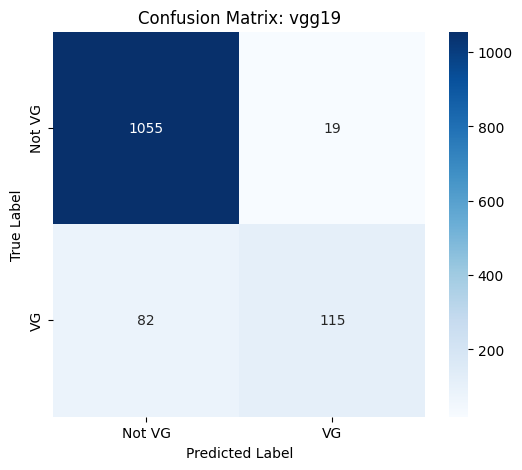


--- Training Final alexnet with Best Params ---


c:\Program Files\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Program Files\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Final Test Metrics (alexnet):
Accuracy: 0.9308 | F1: 0.7720 | AUC: 0.9483


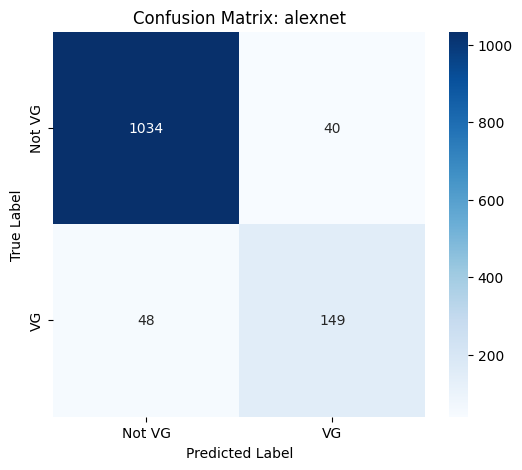

In [13]:
def train_final_model(model_name, best_params, train_ds, test_ds):
    print(f"\n--- Training Final {model_name} with Best Params ---")
    
    # 1. Re-create the model with best params
    model = get_modified_model(model_name)
    
    # 2. Setup Optimizer with Best Params
    lr = best_params['learning_rate']
    wd = best_params['weight_decay']
    opt_name = best_params['optimizer']
    
    if opt_name == "AdamW":
        optimizer = optim.AdamW(model.classifier.parameters(), lr=lr, weight_decay=wd)
    else:
        optimizer = optim.Adam(model.classifier.parameters(), lr=lr, weight_decay=wd)
        
    # 3. Dataloaders (Use Full Train Set now, not subsets)
    bs = best_params['batch_size']
    train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True)
    test_dl = DataLoader(test_ds, batch_size=bs, shuffle=False)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(torch.device("cuda")))
    
    # 4. Train for a fixed number of epochs (e.g., 3-5) for the final result
    trainer = ModelTrainer(model, None) # No trial needed here
    # Note: We just run the loop manually or modify ModelTrainer to work without trial
    # Simple manual loop for final training:
    model.to("cuda")
    
    for epoch in range(3): # Train for 3 epochs
        model.train()
        for imgs, lbls in train_dl:
            imgs, lbls = imgs.to("cuda"), lbls.to("cuda")
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()
            
    # 5. Final Evaluation
    loss, acc, f1, auc, cm = trainer.evaluate(test_dl, criterion)
    
    print(f"Final Test Metrics ({model_name}):")
    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    
    # 6. Plot Confusion Matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not VG', 'VG'], yticklabels=['Not VG', 'VG'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return model

# Run for VGG
final_vgg = train_final_model("vgg19", study_vgg.best_params, train_dataset, test_dataset)

# Run for AlexNet
final_alex = train_final_model("alexnet", study_alex.best_params, train_dataset, test_dataset)

In [14]:
def benchmark_device(device_name, model, dataloader, num_iterations=20):
    print(f"\n--- Benchmarking on {device_name.upper()} ---")
    
    # Move model to device
    device = torch.device(device_name)
    model.to(device)
    model.train()
    
    # Setup standard optimizer/criterion just for the test
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = torch.nn.CrossEntropyLoss()
    
    start_time = time.time()
    
    # Run fixed number of iterations
    for i, (imgs, lbls) in enumerate(dataloader):
        if i >= num_iterations:
            break
            
        imgs, lbls = imgs.to(device), lbls.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        
        # Force GPU synchronization to get accurate time
        if device_name == "cuda":
            torch.cuda.synchronize()
            
    end_time = time.time()
    total_time = end_time - start_time
    
    print(f"Time for {num_iterations} iterations on {device_name}: {total_time:.4f} seconds")
    print(f"Average time per batch: {total_time/num_iterations:.4f} seconds")
    
    return total_time

# --- EXECUTE BENCHMARK ---
# 1. Print System Info (Required by PDF)
print(f"Machine Name: {platform.node()}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
else:
    print("GPU Model: N/A")

# 2. Prepare a small batch of data
# We use the existing train_dataset from your main code
bench_dl = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 3. Use one of your models (e.g., VGG-19) for the test
bench_model = get_modified_model('vgg19')

# 4. Run Benchmark on GPU (if available)
gpu_time = 0
if torch.cuda.is_available():
    gpu_time = benchmark_device("cuda", bench_model, bench_dl)

# 5. Run Benchmark on CPU
cpu_time = benchmark_device("cpu", bench_model, bench_dl)

# 6. Calculate Speedup
if gpu_time > 0:
    speedup = cpu_time / gpu_time
    print(f"\nGPU Speedup: {speedup:.2f}x faster than CPU")

Machine Name: wol06-424-pc
GPU Model: NVIDIA GeForce RTX 4090


c:\Program Files\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Program Files\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



--- Benchmarking on CUDA ---
Time for 20 iterations on cuda: 23.8674 seconds
Average time per batch: 1.1934 seconds

--- Benchmarking on CPU ---
Time for 20 iterations on cpu: 79.8353 seconds
Average time per batch: 3.9918 seconds

GPU Speedup: 3.34x faster than CPU


In [15]:
# Save the model state dictionary
# Assuming 'final_alex' was your winner (based on your previous output)
torch.save(final_alex.state_dict(), "best_classifier.pth")
print("Model saved successfully as 'best_classifier.pth'")

Model saved successfully as 'best_classifier.pth'


In [18]:
# 1. Internal Evaluation Function (No printing needed)
def get_auc(model, dataset):
    if model is None: return 0
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    all_probs = []
    all_labels = []
    dl = DataLoader(dataset, batch_size=32, shuffle=False)
    
    with torch.no_grad():
        for imgs, lbls in dl:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(lbls.numpy())
            
    try:
        return roc_auc_score(all_labels, all_probs)
    except:
        return 0.5

# 2. Compare silently
try:
    vgg_score = get_auc(final_vgg, test_dataset)
except NameError:
    vgg_score = 0

try:
    alex_score = get_auc(final_alex, test_dataset)
except NameError:
    alex_score = 0

# 3. Save the Winner Automatically
winner_name = "alexnet" if alex_score >= vgg_score else "vgg19"
winner_model = final_alex if alex_score >= vgg_score else final_vgg

# Save the weights
torch.save(winner_model.state_dict(), "best_classifier.pth")

# 4. Write the result to a text file so you can read it outside the notebook
with open("WINNER.txt", "w") as f:
    f.write(winner_name)

# 5. Force a popup in the variable explorer (Optional, but helps)
print("DONE. CHECK YOUR FILE EXPLORER for 'WINNER.txt'")

DONE. CHECK YOUR FILE EXPLORER for 'WINNER.txt'
